# HNSW Index Performance Evaluation

Evaluates the `HNSWIndex` 

**Sections**
1. Config & imports
2. Deterministic vector generator (idempotent resume)
3. Idempotent insert runner
4. Insert records
6. Storage metrics
7. Graph structure metrics (layer distribution, degree distribution)
8. Search quality (Recall@k, latency)
9. Summary

In [1]:
import sys, os, json, time, math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path("../..")
sys.path.insert(0, str(PROJECT_ROOT.resolve()))



from Storage.HNSW.hnsw_index import HNSWIndex

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

print("Imports OK")

Imports OK


In [2]:
DIM        = 64
BATCH_SIZE = 10_000

TARGETS = {
    "100k":  100_000,
}

DATA_ROOT   = Path("./eval_data")
INDEX_ROOTS = {scale: DATA_ROOT / f"hnsw_{scale}" for scale in TARGETS}

# Real embeddings file (20M × 384 float32 flat binary)
EMBEDDINGS_PATH = DATA_ROOT / "embeddings.dat"

# HNSW hyperparameters - keep identical across scales for a fair comparison.
HNSW_KWARGS = dict(
    dimension        = DIM,
    M                = 16,
    ef_construction  = 200,
)

# Evaluation parameters
N_QUERY_VECTORS = 200
TOP_K           = 10
EF_VALUES       = [100, 200, 400]

SAVE_EVERY = 500

for p in INDEX_ROOTS.values():
    p.mkdir(parents=True, exist_ok=True)

print("Data dirs:", {k: str(v) for k, v in INDEX_ROOTS.items()})

Data dirs: {'100k': 'eval_data\\hnsw_100k'}


## Deterministic Vector Generator

Each batch of `BATCH_SIZE` vectors is seeded by its **batch index**, so the
same vector at index `i` is always reproduced as `batch[i // BATCH_SIZE][i % BATCH_SIZE]`.
After a crash we only need `vector_count` from the manifest to know where to resume.

In [3]:
_embeddings_mmap = None


def _get_embeddings_mmap() -> np.ndarray:
    global _embeddings_mmap
    if _embeddings_mmap is None:
        if not EMBEDDINGS_PATH.exists():
            raise FileNotFoundError(f"Embeddings file not found: {EMBEDDINGS_PATH}")
        file_size = EMBEDDINGS_PATH.stat().st_size
        total = file_size // (DIM * 4)
        _embeddings_mmap = np.memmap(
            str(EMBEDDINGS_PATH), dtype=np.float32, mode="r", shape=(total, DIM)
        )
        print(f"Loaded embeddings mmap: {total:,} vectors × {DIM} dims  ({file_size / 1e9:.2f} GB)")
    return _embeddings_mmap


def make_batch(batch_idx: int, size: int = BATCH_SIZE, dim: int = DIM) -> np.ndarray:
    """Load a batch of L2-normalised float32 vectors from the embeddings file."""
    mmap = _get_embeddings_mmap()
    start = batch_idx * size
    end = min(start + size, mmap.shape[0])
    vecs = np.array(mmap[start:end], dtype=np.float32)
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return vecs / norms


def make_query_vectors(n: int = N_QUERY_VECTORS, dim: int = DIM, seed: int = None) -> np.ndarray:
    """Load query vectors from beyond the largest insert target (never in the index)."""
    mmap = _get_embeddings_mmap()
    offset = max(TARGETS.values())
    vecs = np.array(mmap[offset : offset + n], dtype=np.float32)
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return vecs / norms


_b0 = make_batch(0)
assert np.allclose(_b0, make_batch(0)), "Loader not deterministic!"
print(f"Batch shape: {_b0.shape}  |  norms ≈ 1: {np.allclose(np.linalg.norm(_b0, axis=1), 1.0)}")

Loaded embeddings mmap: 20,000,000 vectors × 64 dims  (5.12 GB)
Batch shape: (10000, 64)  |  norms ≈ 1: True


## Idempotent Insert

Reads `vector_count` from the manifest, skips already-inserted vectors, then
continues.  Calls `index.save()` every `SAVE_EVERY` inserts so progress is not
lost on a crash - but **not on every single insert**, which is the whole point.

In [4]:
def insert_to_target(
    index: HNSWIndex,
    target: int,
    batch_size: int = BATCH_SIZE,
    save_every: int = SAVE_EVERY,
    report_every: int = 100_000,
) -> None:
    already = index.vector_count
    if already >= target:
        print(f"Already at {already:,} / {target:,} - nothing to do.")
        return

    print(f"Resuming from {already:,} → {target:,}  ({target - already:,} to insert)")

    first_batch  = already // batch_size
    first_offset = already % batch_size
    remaining    = target - already

    t0 = time.perf_counter()
    inserted    = 0
    next_report = report_every
    next_save   = save_every

    with tqdm(total=remaining, unit="vec", unit_scale=True, desc="Inserting") as pbar:
        batch_idx = first_batch
        while inserted < remaining:
            batch = make_batch(batch_idx)

            if batch_idx == first_batch and first_offset > 0:
                batch = batch[first_offset:]

            left = remaining - inserted
            if len(batch) > left:
                batch = batch[:left]

            for vec in batch:
                index.insert(vec)
                inserted += 1
                pbar.update(1)

                if inserted >= next_save:
                    index.save()
                    next_save += save_every

                if inserted >= next_report:
                    elapsed = time.perf_counter() - t0
                    rate    = inserted / elapsed
                    eta_s   = (remaining - inserted) / rate if rate > 0 else float("inf")
                    pbar.set_postfix(
                        rate=f"{rate:,.0f}/s",
                        eta=f"{eta_s/60:.1f}min",
                        layers=index._max_layer,
                    )
                    next_report += report_every

            batch_idx += 1

    index.save()   # final save
    elapsed = time.perf_counter() - t0
    print(f"\nDone. Total: {index.vector_count:,}  |  Time: {elapsed/60:.1f} min  |  Rate: {inserted/elapsed:,.0f} vec/s")

## Insert 100k Records

Safe to re-run - will resume from the current `vector_count`.

In [5]:
idx_100k = HNSWIndex(root_dir=str(INDEX_ROOTS["100k"]), **HNSW_KWARGS)
print(f"Current 100k index state: {idx_100k.vector_count:,} vectors, max_layer={idx_100k._max_layer}")
insert_to_target(idx_100k, target=TARGETS["100k"])

Current 100k index state: 100,000 vectors, max_layer=4
Already at 100,000 / 100,000 - nothing to do.


## Storage Metrics

In [6]:
def fmt_bytes(b: int) -> str:
    for unit in ("B", "KB", "MB", "GB", "TB"):
        if b < 1024:
            return f"{b:.1f} {unit}"
        b /= 1024
    return f"{b:.1f} PB"


def storage_report(scale: str) -> dict:
    root     = INDEX_ROOTS[scale]
    manifest = json.loads((root / "manifest.json").read_text())
    n   = manifest["vector_count"]
    dim = manifest["dimension"]

    files = {
        "vectors.dat":  root / "vectors.dat",
        "graph.npz":    root / "graph.npz",
        "manifest.json": root / "manifest.json",
    }
    sizes = {name: p.stat().st_size for name, p in files.items() if p.exists()}
    sizes["TOTAL"] = sum(sizes.values())

    # Raw vector footprint (uncompressed reference)
    raw_vectors_bytes = n * dim * 4
    graph_data = np.load(str(root / "graph.npz"), allow_pickle=False)
    levels = graph_data["levels"].tolist()
    max_layer = max(levels) if levels else 0
    nodes_per_layer = [
        sum(1 for lv in levels if lv >= lc)
        for lc in range(max_layer + 1)
    ]

    return {
        "scale":             scale,
        "vectors":           n,
        "dim":               dim,
        "max_layer":         max_layer,
        "nodes_per_layer":   nodes_per_layer,
        "raw_vectors_bytes": raw_vectors_bytes,
        "sizes_bytes":       sizes,
        "_levels":           levels,
    }


reports = {}
for scale in TARGETS:
    root = INDEX_ROOTS[scale]
    if not (root / "manifest.json").exists():
        print(f"[{scale}] index not built yet - skip")
        continue
    r = storage_report(scale)
    reports[scale] = r
    print(f"\n{'─'*52}")
    print(f"  Scale        : {r['scale']}  ({r['vectors']:,} vectors, dim={r['dim']})")
    print(f"  Max layer    : {r['max_layer']}")
    print(f"  Nodes / layer: {r['nodes_per_layer']}")
    print(f"  Raw vectors  : {fmt_bytes(r['raw_vectors_bytes'])}")
    print(f"  Storage breakdown:")
    for name, sz in r["sizes_bytes"].items():
        ratio = f"  ({sz / r['raw_vectors_bytes'] * 100:.1f}% of raw)" if name == "graph.npz" else ""
        print(f"    {name:<18s} {fmt_bytes(sz):>10}{ratio}")


────────────────────────────────────────────────────
  Scale        : 100k  (100,000 vectors, dim=64)
  Max layer    : 4
  Nodes / layer: [100000, 6322, 392, 28, 1]
  Raw vectors  : 24.4 MB
  Storage breakdown:
    vectors.dat           24.4 MB
    graph.npz              6.5 MB  (26.7% of raw)
    manifest.json          84.0 B
    TOTAL                 30.9 MB


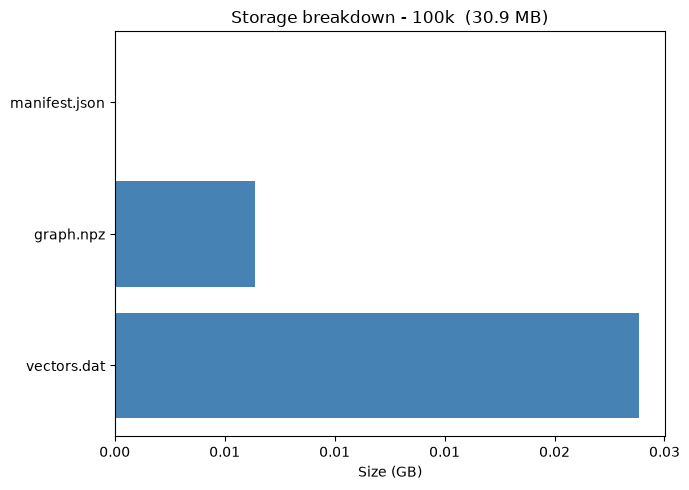

In [7]:
if reports:
    fig, axes = plt.subplots(1, len(reports), figsize=(7 * len(reports), 5))
    if len(reports) == 1:
        axes = [axes]

    for ax, (scale, r) in zip(axes, reports.items()):
        sizes = {k: v / (1024**3) for k, v in r["sizes_bytes"].items() if k != "TOTAL"}
        ax.barh(list(sizes.keys()), list(sizes.values()), color="steelblue")
        ax.set_xlabel("Size (GB)")
        ax.set_title(f"Storage breakdown - {scale}  ({fmt_bytes(r['sizes_bytes']['TOTAL'])})")
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    plt.tight_layout()
    plt.savefig(DATA_ROOT / "storage_breakdown.png", dpi=120)
    plt.show()

---
## Graph Structure Metrics

| Metric | What it measures |
|--------|------------------|
| **Layer population** | Nodes per layer - should decay exponentially (log scale) |
| **Degree distribution (layer 0)** | Neighbour counts - should peak near M0=2M |
| **Degree distribution (layer 1+)** | Should peak near M |
| **Avg degree per layer** | How full the adjacency lists are |
| **Entry-point level** | Higher = deeper navigation hierarchy |

---
## Sanity Check - vectors.dat / graph / manifest consistency

In [8]:
def graph_structure_metrics(index: HNSWIndex, scale: str) -> dict:
    levels    = index._levels
    neighbors = index._neighbors
    N         = len(levels)
    max_lc    = index._max_layer

    # Nodes per layer
    nodes_per_layer = [
        sum(1 for lv in levels if lv >= lc)
        for lc in range(max_lc + 1)
    ]

    # Degree distribution per layer
    degree_dist: dict[int, list[int]] = {}
    avg_degree:  dict[int, float]     = {}
    for lc in range(max_lc + 1):
        degs = [
            len(neighbors[i][lc])
            for i in range(N)
            if levels[i] >= lc
        ]
        degree_dist[lc] = degs
        avg_degree[lc]  = float(np.mean(degs)) if degs else 0.0

    # Ratio of actual layer-0 count to theoretical (M_L distribution)
    # Theoretical: E[nodes at layer l] = N * (1/M)^l
    M = index.M
    theoretical = [N * (1.0 / M) ** lc for lc in range(max_lc + 1)]

    return {
        "scale":           scale,
        "N":               N,
        "max_layer":       max_lc,
        "entry_point":     index._entry_point,
        "entry_point_level": levels[index._entry_point] if index._entry_point >= 0 else -1,
        "nodes_per_layer": nodes_per_layer,
        "theoretical_nodes_per_layer": theoretical,
        "degree_dist":     degree_dist,
        "avg_degree":      avg_degree,
        "M":               M,
        "M0":              index.M0,
    }


graph_results = {}
for scale in TARGETS:
    root = INDEX_ROOTS[scale]
    if not (root / "manifest.json").exists():
        print(f"[{scale}] skip - not built")
        continue
    idx = HNSWIndex(root_dir=str(root), **HNSW_KWARGS)
    if idx.vector_count == 0:
        continue
    r = graph_structure_metrics(idx, scale)
    graph_results[scale] = r
    print(f"\n[{scale}]")
    print(f"  Vectors: {r['N']:,}  |  max_layer: {r['max_layer']}  |  entry_point level: {r['entry_point_level']}")
    print(f"  Nodes per layer (actual vs theoretical):")
    for lc in range(r['max_layer'] + 1):
        actual = r['nodes_per_layer'][lc]
        theory = r['theoretical_nodes_per_layer'][lc]
        print(f"    Layer {lc}: {actual:>8,}  (theory {theory:>10,.0f})  avg_degree={r['avg_degree'][lc]:.2f}")


[100k]
  Vectors: 100,000  |  max_layer: 4  |  entry_point level: 4
  Nodes per layer (actual vs theoretical):
    Layer 0:  100,000  (theory    100,000)  avg_degree=25.57
    Layer 1:    6,322  (theory      6,250)  avg_degree=16.00
    Layer 2:      392  (theory        391)  avg_degree=16.00
    Layer 3:       28  (theory         24)  avg_degree=16.00
    Layer 4:        1  (theory          2)  avg_degree=0.00


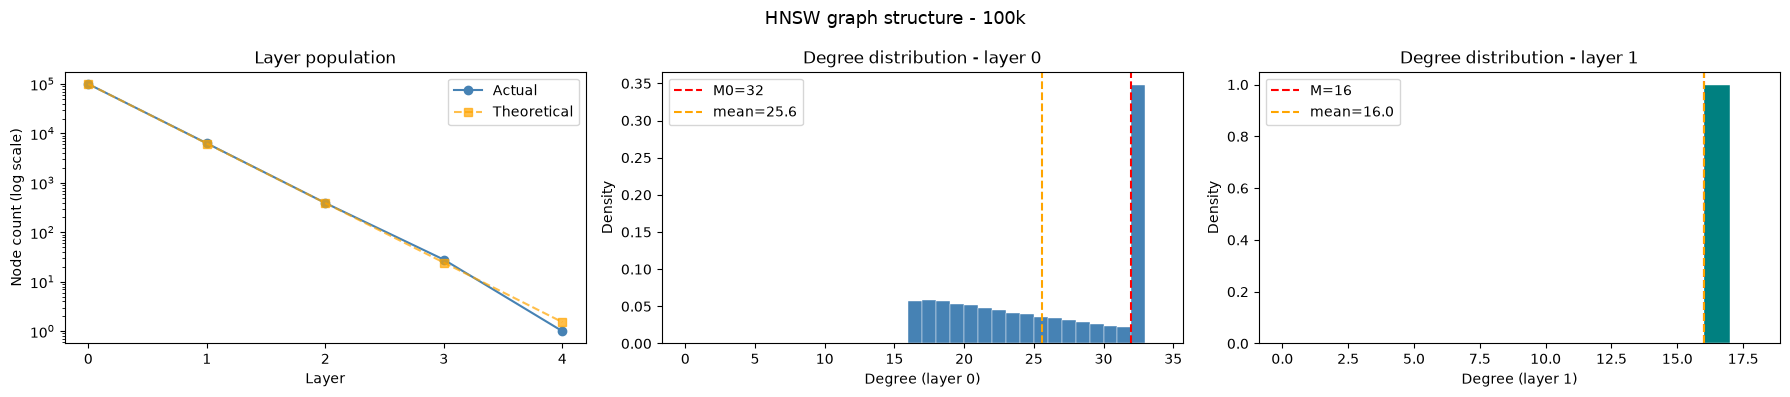

In [9]:
# Layer population (log scale) + degree distribution at layer 0 and layer 1
if graph_results:
    for scale, r in graph_results.items():
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle(f"HNSW graph structure - {scale}", fontsize=13)

        ax = axes[0]
        layers   = list(range(r['max_layer'] + 1))
        actual   = r['nodes_per_layer']
        theory   = r['theoretical_nodes_per_layer']
        ax.semilogy(layers, actual, 'o-', label='Actual',      color='steelblue')
        ax.semilogy(layers, theory, 's--', label='Theoretical', color='orange', alpha=0.7)
        ax.set_xlabel("Layer")
        ax.set_ylabel("Node count (log scale)")
        ax.set_title("Layer population")
        ax.legend()
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

        ax = axes[1]
        degs0 = r['degree_dist'].get(0, [])
        if degs0:
            ax.hist(degs0, bins=range(0, r['M0'] + 3), color='steelblue',
                    edgecolor='white', linewidth=0.3, density=True)
            ax.axvline(r['M0'], color='red', linestyle='--', label=f"M0={r['M0']}")
            ax.axvline(np.mean(degs0), color='orange', linestyle='--',
                       label=f"mean={np.mean(degs0):.1f}")
        ax.set_xlabel("Degree (layer 0)")
        ax.set_ylabel("Density")
        ax.set_title("Degree distribution - layer 0")
        ax.legend()

        ax = axes[2]
        degs1 = r['degree_dist'].get(1, [])
        if degs1:
            ax.hist(degs1, bins=range(0, r['M'] + 3), color='teal',
                    edgecolor='white', linewidth=0.3, density=True)
            ax.axvline(r['M'], color='red', linestyle='--', label=f"M={r['M']}")
            ax.axvline(np.mean(degs1), color='orange', linestyle='--',
                       label=f"mean={np.mean(degs1):.1f}")
        ax.set_xlabel("Degree (layer 1)")
        ax.set_ylabel("Density")
        ax.set_title("Degree distribution - layer 1")
        ax.legend()

        plt.tight_layout()
        plt.savefig(DATA_ROOT / f"graph_structure_{scale}.png", dpi=120)
        plt.show()

---
## Search Quality Metrics

Compares HNSW results against brute-force (exact) nearest neighbours.

| Metric | Definition |
|--------|------------|
| **Recall@k** | `|HNSW_top_k ∩ BF_top_k| / k` |
| **Mean reciprocal rank** | `1 / rank_of_first_true_positive` |
| **HNSW latency (ms)** | Wall time per query at a given `ef` |
| **BF latency (ms)** | Wall time per query (mmap full scan) |

We also sweep `ef` to produce a **recall-vs-latency curve** - the key
HNSW-specific trade-off that has no direct IVF equivalent.

In [10]:
TOP_K = 10

def brute_force_topk(vectors_mmap: np.ndarray, query: np.ndarray, k: int) -> list[int]:
    sims = vectors_mmap @ query
    top  = np.argpartition(sims, -k)[-k:]
    return top[np.argsort(sims[top])[::-1]].tolist()


def search_quality(
    index: HNSWIndex,
    scale: str,
    top_k: int = TOP_K,
    n_queries: int = N_QUERY_VECTORS,
    ef_values: list[int] = EF_VALUES,
) -> dict:
    root  = INDEX_ROOTS[scale]
    n     = index.vector_count
    dim   = index.dimension

    queries = make_query_vectors(n=n_queries, dim=dim)
    vecs_mmap = np.memmap(str(root / "vectors.dat"), dtype=np.float32, mode="r", shape=(n, dim))

    # Pre-compute brute-force ground truth once
    bf_times  = []
    bf_hits_ordered = []  # Keep the exact sorted order to identify the #1 true match
    for q in tqdm(queries, desc=f"BF ground truth {scale}", leave=False):
        t0 = time.perf_counter()
        hits = brute_force_topk(vecs_mmap, q, top_k)
        bf_times.append((time.perf_counter() - t0) * 1000)
        bf_hits_ordered.append(hits)

    # Sweep ef values
    ef_curve = []   # list of {ef, recall, latency_mean, latency_p99}
    for ef in ef_values:
        recalls   = []
        mrrs      = []
        hnsw_times = []
        
        for q, gt_ordered in zip(queries, bf_hits_ordered):
            t0 = time.perf_counter()
            hits = [vid for vid, _ in index.query(q, top_k=top_k, ef=ef)]
            hnsw_times.append((time.perf_counter() - t0) * 1000)

            # 1. Identify the absolute best ground truth match
            true_best_match = gt_ordered[0]
            
            # 2. Convert ground truth to set for standard Recall@K calculation
            gt_set = set(gt_ordered) 

            # Calculate Recall
            recalls.append(len(set(hits) & gt_set) / top_k)
            
            # Calculate MRR checking ONLY against the #1 true match
            mrr_val = 0.0
            for rank, vid in enumerate(hits, 1):
                if vid == true_best_match:
                    mrr_val = 1.0 / rank
                    break
            mrrs.append(mrr_val)

        ef_curve.append({
            "ef":           ef,
            "recall":       float(np.mean(recalls)),
            "mrr":          float(np.mean(mrrs)),
            "latency_mean": float(np.mean(hnsw_times)),
            "latency_p99":  float(np.percentile(hnsw_times, 99)),
            "_recalls":     recalls,
            "_times":       hnsw_times,
        })
        print(f"  ef={ef:>4}  recall={ef_curve[-1]['recall']:.4f}  "
              f"latency={ef_curve[-1]['latency_mean']:.2f}ms")

    del vecs_mmap

    # Default operating point (ef = top_k)
    default = next((x for x in ef_curve if x["ef"] == max(top_k, 50)), ef_curve[-1])

    return {
        "scale":       scale,
        "ef_curve":    ef_curve,
        "default_ef":  default,
        "bf_latency":  float(np.mean(bf_times)),
    }


search_results = {}
for scale in TARGETS:
    root = INDEX_ROOTS[scale]
    if not (root / "manifest.json").exists():
        continue
    idx = HNSWIndex(root_dir=str(root), **HNSW_KWARGS)
    if idx.vector_count == 0:
        continue
    print(f"\nRunning search eval on {scale} index ({idx.vector_count:,} vectors)...")
    r = search_quality(idx, scale)
    search_results[scale] = r
    def_ = r["default_ef"]
    print(f"Recall@{TOP_K} (default ef={def_['ef']}) = {def_['recall']:.4f}")
    print(f"MRR  = {def_['mrr']:.4f}")
    print(f"HNSW latency mean/p99  = {def_['latency_mean']:.2f} ms / {def_['latency_p99']:.2f} ms")
    print(f"BF latency mean  = {r['bf_latency']:.2f} ms")


Running search eval on 100k index (100,000 vectors)...


BF ground truth 100k:   0%|          | 0/200 [00:00<?, ?it/s]

  ef= 100  recall=0.9750  latency=1.81ms
  ef= 200  recall=0.9880  latency=3.33ms
  ef= 400  recall=0.9920  latency=5.97ms
Recall@10 (default ef=400) = 0.9920
MRR  = 0.9875
HNSW latency mean/p99  = 5.97 ms / 8.37 ms
BF latency mean  = 0.29 ms


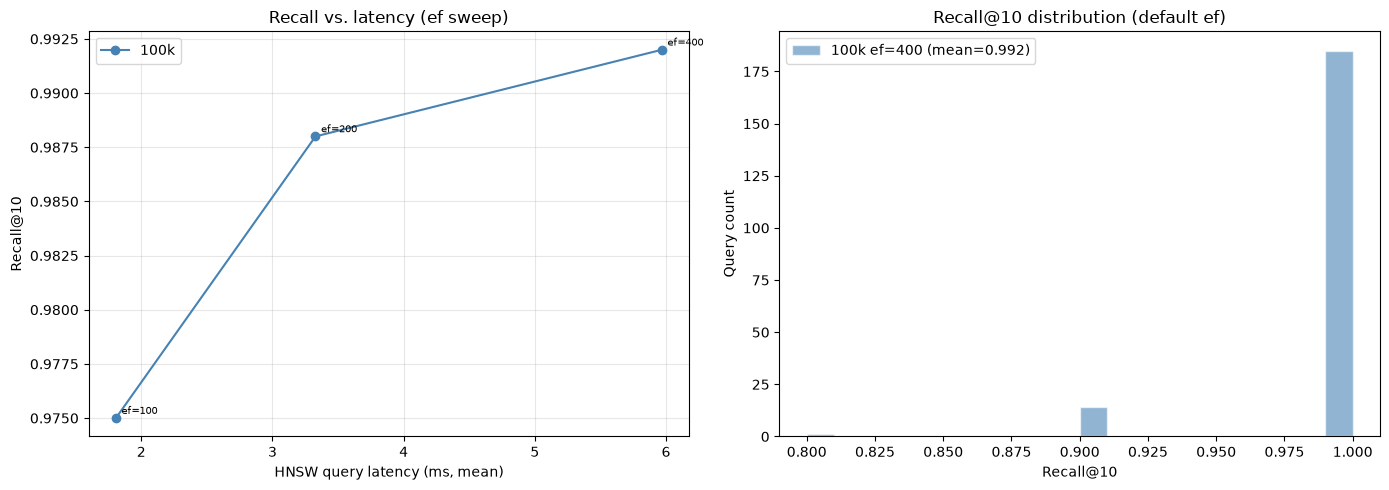

In [11]:

if search_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = {"100k": "steelblue", "10M": "darkorange"}

    ax = axes[0]
    for scale, r in search_results.items():
        xs = [pt["latency_mean"] for pt in r["ef_curve"]]
        ys = [pt["recall"]       for pt in r["ef_curve"]]
        ax.plot(xs, ys, 'o-', label=scale, color=colors[scale])
        for pt in r["ef_curve"]:
            ax.annotate(f"ef={pt['ef']}",
                        (pt["latency_mean"], pt["recall"]),
                        textcoords="offset points", xytext=(4, 3), fontsize=7)
    ax.set_xlabel("HNSW query latency (ms, mean)")
    ax.set_ylabel(f"Recall@{TOP_K}")
    ax.set_title("Recall vs. latency (ef sweep)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for scale, r in search_results.items():
        default = r["default_ef"]
        ax.hist(
            default["_recalls"], bins=20, alpha=0.6,
            label=f"{scale} ef={default['ef']} (mean={default['recall']:.3f})",
            color=colors[scale], edgecolor="white",
        )
    ax.set_xlabel(f"Recall@{TOP_K}")
    ax.set_ylabel("Query count")
    ax.set_title(f"Recall@{TOP_K} distribution (default ef)")
    ax.legend()

    plt.tight_layout()
    plt.savefig(DATA_ROOT / "search_quality.png", dpi=120)
    plt.show()

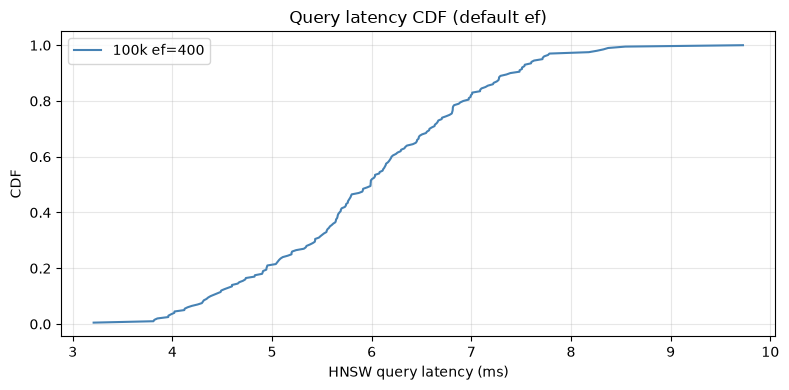

In [12]:
# Latency CDF at default ef
if search_results:
    fig, ax = plt.subplots(figsize=(8, 4))
    for scale, r in search_results.items():
        default = r["default_ef"]
        times = sorted(default["_times"])
        cdf   = np.arange(1, len(times) + 1) / len(times)
        ax.plot(times, cdf, label=f"{scale} ef={default['ef']}", color=colors[scale])
    ax.set_xlabel("HNSW query latency (ms)")
    ax.set_ylabel("CDF")
    ax.set_title("Query latency CDF (default ef)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_ROOT / "latency_cdf.png", dpi=120)
    plt.show()

In [13]:
def row(label, key_fn, missing="-"):

    print(f"{label:<42} {str(key_fn(scale)):>12}")


print(f"{'Metric':<42} {'100k':>12}")
print("─" * 68)

row("Vectors inserted",
    lambda s: f"{graph_results[s]['N']:,}")
row("Max layer",
    lambda s: graph_results[s]['max_layer'])
row("Entry-point level",
    lambda s: graph_results[s]['entry_point_level'])
row("Avg degree layer 0  (cap=M0)",
    lambda s: f"{graph_results[s]['avg_degree'][0]:.2f}  (cap={graph_results[s]['M0']})")
row("Avg degree layer 1  (cap=M)",
    lambda s: f"{graph_results[s]['avg_degree'].get(1, float('nan')):.2f}  (cap={graph_results[s]['M']})")
row("Total storage",
    lambda s: fmt_bytes(reports[s]['sizes_bytes']['TOTAL']))
row("  - vectors.dat",
    lambda s: fmt_bytes(reports[s]['sizes_bytes']['vectors.dat']))
row("  - graph.npz",
    lambda s: fmt_bytes(reports[s]['sizes_bytes']['graph.npz']))
row(f"Recall@{TOP_K} (default ef)",
    lambda s: f"{search_results[s]['default_ef']['recall']:.4f}")
row("MRR (default ef)",
    lambda s: f"{search_results[s]['default_ef']['mrr']:.4f}")
row("HNSW latency mean (ms)",
    lambda s: f"{search_results[s]['default_ef']['latency_mean']:.2f}")
row("HNSW latency p99  (ms)",
    lambda s: f"{search_results[s]['default_ef']['latency_p99']:.2f}")
row("BF   latency mean (ms)",
    lambda s: f"{search_results[s]['bf_latency']:.2f}")
row("Best recall point (ef)",
    lambda s: f"{max(search_results[s]['ef_curve'], key=lambda x: x['recall'])['recall']:.4f}  "
              f"@ ef={max(search_results[s]['ef_curve'], key=lambda x: x['recall'])['ef']}")

Metric                                             100k
────────────────────────────────────────────────────────────────────
Vectors inserted                                100,000
Max layer                                             4
Entry-point level                                     4
Avg degree layer 0  (cap=M0)               25.57  (cap=32)
Avg degree layer 1  (cap=M)                16.00  (cap=16)
Total storage                                   30.9 MB
  - vectors.dat                                 24.4 MB
  - graph.npz                                    6.5 MB
Recall@10 (default ef)                           0.9920
MRR (default ef)                                 0.9875
HNSW latency mean (ms)                             5.97
HNSW latency p99  (ms)                             8.37
BF   latency mean (ms)                             0.29
Best recall point (ef)                     0.9920  @ ef=400


---
## FAISS HNSW Baseline

Builds a faiss `IndexHNSWFlat` with the **same M and ef_construction** on the
same vectors so recall numbers are directly comparable.  faiss uses inner-product
(cosine on unit vectors) internally - same distance as our index.

In [14]:
try:
    import faiss
    FAISS_OK = True
    print(f"faiss {faiss.__version__}  (GPU count: {faiss.get_num_gpus()})")
except ImportError:
    FAISS_OK = False
    print("faiss not installed - run:  pip install faiss-cpu")

faiss 1.14.3  (GPU count: 0)


In [15]:
faiss_results = {}

if not FAISS_OK:
    print("faiss not available")
else:
    for scale in TARGETS:
        root = INDEX_ROOTS[scale]
        if not (root / "manifest.json").exists():
            print(f"[{scale}] index not built yet - skip")
            continue

        manifest = json.loads((root / "manifest.json").read_text())
        n   = manifest["vector_count"]
        dim = manifest["dimension"]
        if n == 0:
            continue

        print(f"\nBuilding faiss HNSW baseline for {scale} ({n:,} vectors, dim={dim})...")

        # Load the exact same vectors already on disk.
        vecs_all = np.memmap(str(root / "vectors.dat"), dtype=np.float32, mode="r", shape=(n, dim))
        vecs_np  = np.array(vecs_all)   # copy to RAM (faiss needs contiguous array)
        del vecs_all

        M_faiss  = HNSW_KWARGS["M"]
        ef_c     = HNSW_KWARGS["ef_construction"]

        idx_faiss = faiss.IndexHNSWFlat(dim, M_faiss, faiss.METRIC_INNER_PRODUCT)
        idx_faiss.hnsw.efConstruction = ef_c

        t0 = time.perf_counter()
        idx_faiss.add(vecs_np)
        build_time = time.perf_counter() - t0
        print(f"  Build time: {build_time:.1f}s  ({n / build_time:,.0f} vec/s)")

        # Evaluate over the same query set and ef sweep.
        queries   = make_query_vectors(n=N_QUERY_VECTORS, dim=dim)
        vecs_bf   = np.memmap(
            str(root / "vectors.dat"), dtype=np.float32, mode="r", shape=(n, dim)
        )

        bf_hits = []
        for q in queries:
            gt = brute_force_topk(vecs_bf, q, TOP_K)
            bf_hits.append(set(gt))
        del vecs_bf

        ef_curve_faiss = []
        for ef in EF_VALUES:
            idx_faiss.hnsw.efSearch = ef
            recalls = []
            times   = []
            for q, gt in zip(queries, bf_hits):
                q_arr = q[np.newaxis, :].astype(np.float32)
                t0    = time.perf_counter()
                _, I  = idx_faiss.search(q_arr, TOP_K)
                times.append((time.perf_counter() - t0) * 1000)
                recalls.append(len(set(I[0].tolist()) & gt) / TOP_K)

            ef_curve_faiss.append({
                "ef":           ef,
                "recall":       float(np.mean(recalls)),
                "latency_mean": float(np.mean(times)),
                "latency_p99":  float(np.percentile(times, 99)),
                "_recalls":     recalls,
                "_times":       times,
            })
            print(f"  ef={ef:>4}  recall={ef_curve_faiss[-1]['recall']:.4f}"
                  f"  latency={ef_curve_faiss[-1]['latency_mean']:.2f}ms")

        faiss_results[scale] = {
            "ef_curve":   ef_curve_faiss,
            "build_time": build_time,
        }
        default_f = next((x for x in ef_curve_faiss if x["ef"] == max(TOP_K, 50)), ef_curve_faiss[-1])
        print(f"  faiss Recall@{TOP_K} (ef={default_f['ef']}) = {default_f['recall']:.4f}")


Building faiss HNSW baseline for 100k (100,000 vectors, dim=64)...
  Build time: 1.7s  (58,226 vec/s)
  ef= 100  recall=0.9775  latency=0.10ms
  ef= 200  recall=0.9900  latency=0.16ms
  ef= 400  recall=0.9925  latency=0.34ms
  faiss Recall@10 (ef=400) = 0.9925


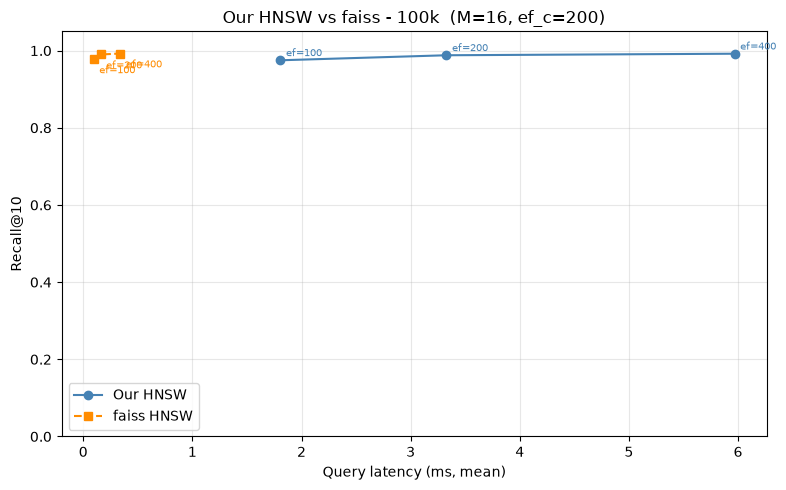

In [16]:

if search_results and faiss_results:
    scales = [s for s in TARGETS if s in search_results and s in faiss_results]
    if scales:
        fig, axes = plt.subplots(1, len(scales), figsize=(8 * len(scales), 5))
        if len(scales) == 1:
            axes = [axes]

        for ax, scale in zip(axes, scales):
            ours  = search_results[scale]["ef_curve"]
            fss   = faiss_results[scale]["ef_curve"]

            ax.plot(
                [p["latency_mean"] for p in ours],
                [p["recall"] for p in ours],
                'o-', label="Our HNSW", color="steelblue",
            )
            for p in ours:
                ax.annotate(f"ef={p['ef']}", (p["latency_mean"], p["recall"]),
                            textcoords="offset points", xytext=(4, 3), fontsize=7,
                            color="steelblue")

            ax.plot(
                [p["latency_mean"] for p in fss],
                [p["recall"] for p in fss],
                's--', label="faiss HNSW", color="darkorange",
            )
            for p in fss:
                ax.annotate(f"ef={p['ef']}", (p["latency_mean"], p["recall"]),
                            textcoords="offset points", xytext=(4, -10), fontsize=7,
                            color="darkorange")

            ax.set_xlabel("Query latency (ms, mean)")
            ax.set_ylabel(f"Recall@{TOP_K}")
            ax.set_title(f"Our HNSW vs faiss - {scale}  (M={HNSW_KWARGS['M']}, ef_c={HNSW_KWARGS['ef_construction']})")
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.05)

        plt.tight_layout()
        plt.savefig(DATA_ROOT / "hnsw_vs_faiss.png", dpi=120)
        plt.show()

---
## Standalone Figure Export for the GP Book

Exports individual figures used in `ch04_design.tex`:

| File saved | LaTeX label | Description |
|------------|-------------|-------------|
| `eval_data/layer_population.png` | `fig:hnsw_layer_pop` | Layer population log-scale |
| `eval_data/ef_recall_latency.png` | `fig:hnsw_recall_latency` | Recall vs. latency ef sweep |

**After running this cell**, copy the two PNGs to `GP-book/images/`:
```
cp eval_data/layer_population.png    ../../GP-book/images/layer_population.png
cp eval_data/ef_recall_latency.png   ../../GP-book/images/ef_recall_latency.png
```

Saved: eval_data\layer_population.png


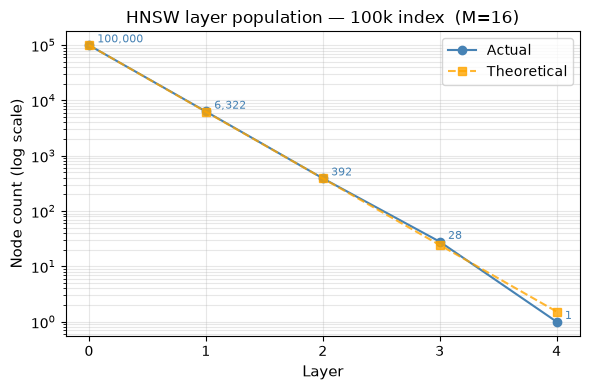

Saved: eval_data\ef_recall_latency.png


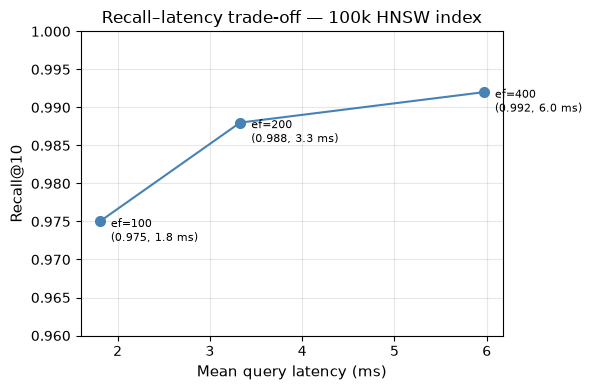

Book images dir not found at G:\Engineering\GP\GP-book\images — copy files manually.


In [ ]:

if graph_results:
    scale = "100k"
    r = graph_results[scale]
    layers = list(range(r["max_layer"] + 1))
    actual = r["nodes_per_layer"]
    theory = r["theoretical_nodes_per_layer"]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.semilogy(layers, actual, "o-", label="Actual",       color="steelblue", linewidth=1.5)
    ax.semilogy(layers, theory, "s--", label="Theoretical", color="orange",    linewidth=1.5, alpha=0.8)
    for lc, (a, t) in enumerate(zip(actual, theory)):
        ax.annotate(f"{a:,}", (lc, a), textcoords="offset points",
                    xytext=(6, 2), fontsize=8, color="steelblue")
    ax.set_xlabel("Layer", fontsize=11)
    ax.set_ylabel("Node count (log scale)", fontsize=11)
    ax.set_title(f"HNSW layer population — {scale} index  (M={HNSW_KWARGS['M']})", fontsize=12)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=10)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    out = DATA_ROOT / "layer_population.png"
    fig.savefig(out, dpi=150)
    print(f"Saved: {out}")
    plt.show()

# ── Standalone: ef-sweep recall vs latency (fig:hnsw_recall_latency) ────────
if search_results:
    scale = "100k"
    r = search_results[scale]

    fig, ax = plt.subplots(figsize=(6, 4))
    xs = [pt["latency_mean"] for pt in r["ef_curve"]]
    ys = [pt["recall"]       for pt in r["ef_curve"]]
    ax.plot(xs, ys, "o-", color="steelblue", linewidth=1.5, markersize=7)
    for pt in r["ef_curve"]:
        ax.annotate(
            f"ef={pt['ef']}\n({pt['recall']:.3f}, {pt['latency_mean']:.1f} ms)",
            (pt["latency_mean"], pt["recall"]),
            textcoords="offset points", xytext=(8, -14), fontsize=8,
        )
    ax.set_xlabel("Mean query latency (ms)", fontsize=11)
    ax.set_ylabel(f"Recall@{TOP_K}", fontsize=11)
    ax.set_title(f"Recall–latency trade-off — {scale} HNSW index", fontsize=12)
    ax.set_ylim(0.96, 1.00)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = DATA_ROOT / "ef_recall_latency.png"
    fig.savefig(out, dpi=150)
    print(f"Saved: {out}")
    plt.show()


import shutil
BOOK_IMAGES = Path("../../GP-book/images")
if BOOK_IMAGES.exists():
    for fname in ("layer_population.png", "ef_recall_latency.png"):
        src = DATA_ROOT / fname
        if src.exists():
            shutil.copy2(src, BOOK_IMAGES / fname)
            print(f"Copied → {BOOK_IMAGES / fname}")
else:
    print(f"Book images dir not found at {BOOK_IMAGES.resolve()} — copy files manually.")